# Picchi al variare dell'intensità in tre diversi spot

In [1]:
from varshni_subroutines import *
from qp2_subroutines import fit_N_gaussiane, gaussiana, N_gaussiane

import warnings
warnings.filterwarnings("ignore", category=pd.errors.ParserWarning)

## Parte 0: nomi file e funzioni

In [2]:
# Nomi file 
# orangeF sta per filtro arancione
campione_1 = 'C240830_'
campione_2 = 'C240920_'
d_o_emi = ['0', '0o5', '1', '1o5', '2', '2o5', '3']#, '3o5']
d_o_ass = ['0', '1']
arr_spot = [1, 2, 3]

In [3]:
col = ['red', 'green', 'magenta', 'purple', 'peru', 'cyan', 
       'olive', 'goldenrod', 'black', 'sienna', 'steelblue', 'crimson']

In [4]:
# per tunare l'errore
n_acq = 11

In [5]:
def trasla_counts (waveln, counts):
    mask = (waveln < 650) 
    help = counts[mask]
    i_max = np.argmax(help)
    help2 = np.concatenate((help[:i_max-10], help[i_max+10:]))
    
    media  = np.mean(help2)
    dev = np.std(help2)
    
    if media > 0.08:
        return counts - media + 5*dev/2
    elif media > 0.06:
        return counts - media + 3*dev/2
    elif media > 0.04:
        return counts - media + dev
    elif media > 0.02:
        return counts - media + 2*dev/3
    elif media > 0.01:
        return counts - media + dev/2
    else:
        return counts + dev/2

#### poi plotterò sovrapposte le regioni QD con emi=1, ass=0

In [6]:
x_sovra = []
y_sovra = []

## CAMPIONE 2 con qd

In [7]:
raccoglitore = {
    'spot1': {
        'ass=0': {
            'emi=0o5':  [],
            'emi=1':    [],
            'emi=1o5':  [],
            'emi=2':    [],
            'emi=2o5':  [],
            'emi=3':    []
        },
        'ass=1': []
    },
    'spot2': {
        'ass=0': {
            'emi=0o5':  [],
            'emi=1':    [],
            'emi=1o5':  [],
            'emi=2':    [],
            'emi=2o5':  [],
            'emi=3':    []
        },
        'ass=1': []
    },
    'spot3': {
        'ass=0': {
            'emi=0o5':  [],
            'emi=1':    [],
            'emi=1o5':  [],
            'emi=2':    [],
            'emi=2o5':  [],
            'emi=3':    []
        },
        'ass=1': []
    }
}

NameError: name 'popt2' is not defined

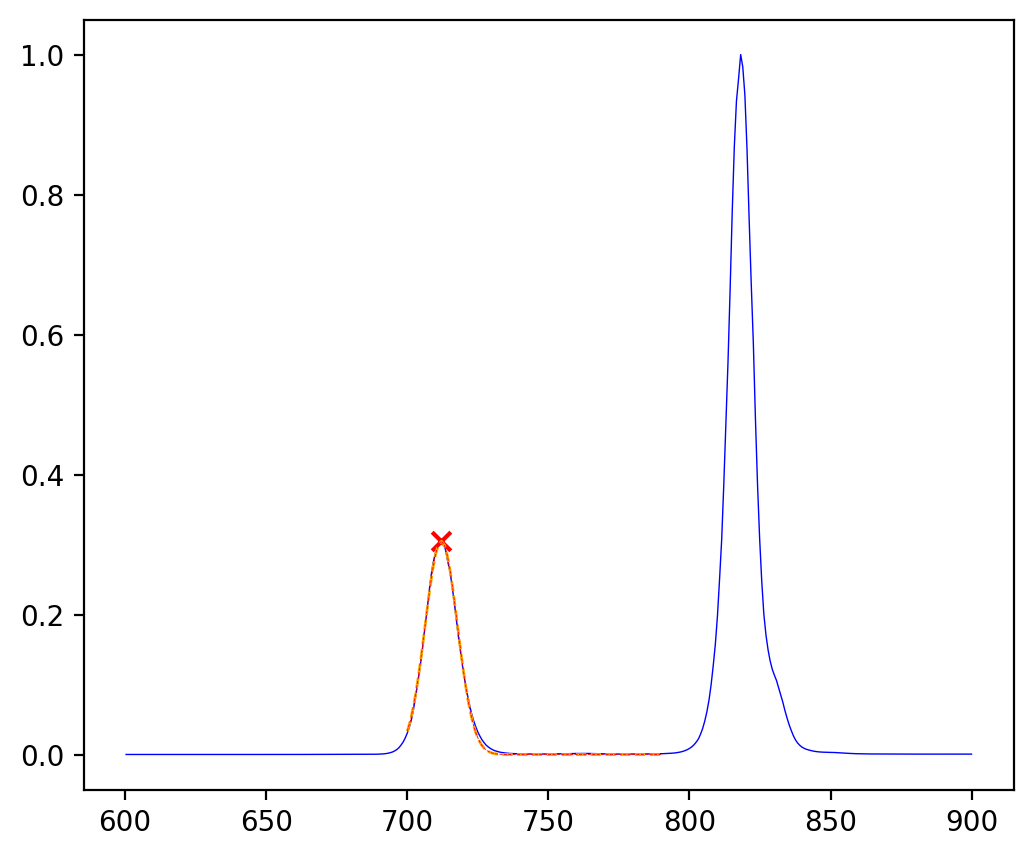

In [8]:
for ass in d_o_ass:
    emi_list = d_o_emi[1:] if ass == '0' else ['0']  # Per ass=1 usa solo emi='0'
    
    # Per ciascuno degli emi > 0 se ass=0, solo emi=0 se ass=1
    for emi in emi_list:
        arr_energia = []

        # Ciclo sugli spot
        for spot in arr_spot:
        
            nome_file = spot_name(campione_1, emi, ass, spot, cartella='data/tre_spot/')
            waveln, counts = leggi_file(nome_file)
            
            # converto 
            waveln, counts = np.array(waveln), np.array(counts)
            
            # normalizzo i counts
            maximum = np.max(counts)
            counts = counts / maximum
            
            # traslo per correggere lo spostamento dovuto al rumore
            counts = trasla_counts(waveln, counts)
                
            # Plot
            plt.figure(figsize=(6,5), dpi=200)
            plt.plot(waveln, counts, linestyle='-', color='b', linewidth=0.5, zorder=1)
            
            ## ## ## ## # FIT # ## ## ## ##
            result = {}
            
            result['Regione 1'] = []

            # TODO: PASSARE I POPT DELLA REGIONE 1 AL FIT DELLE REGIONI INSIEME
            ## REGIONE 1 ##
            
            # isolo regione 700 < x < 800 [REGIONE 1]
            mask1 = (waveln > 700) & (waveln < 790)
            x_fit1 = waveln[mask1]
            y_fit1 = counts[mask1]
            
            # impostazione parametri: ogni entrata è una tripla (a, mu, sigma) [REGIONE 1]
            params1 = [
                (0.2, 730, 50) # il picco del bulk sempre presente
            ]
            
            # Set dei bounds [REGIONE 1]
            low1 = [0, 700, 0] * len(params1)  # Es: A >= 0, mu >= 1500, sigma >= 10 [0.007, inf, 4]
            upp1 = [10, 790, 200] * len(params1)  # Limiti superiori
                
            
            popt1, pcov1, chi2_reduced1 = fit_N_gaussiane(x_fit1, y_fit1, params1, 
                                                        bounds=(low1,upp1), 
                                                        N_MAX_GAUSS=2,
                                                        n_acq=n_acq,
                                                        PREVENT_OVERFIT=False)
            
            # HACK: SE USI IL FIT DELLE REGIONI INSIEME QUESTO PLOT È RIDONDANTE
            ## PLOT CURVA FIT [REGIONE 1] ##
            x_plot1 = np.linspace(700, 790, 90)
            y_plot1 = N_gaussiane(x_plot1, *popt1)
            plt.plot(x_plot1, y_plot1, linestyle='--', color='orange', label=f"Fit", linewidth=1, zorder=2)
                
            # estraggo da popt i parametri ottimizzati [REGIONE 1]
            valori1 = [] # inizializzo
            for i in range(0, round(len(popt1)/3)):
                valori1.append((popt1[3*i], popt1[3*i+1], popt1[3*i+2]))
                
            # li imposto per la prossima gaussiana
            params1 = valori1
            
            # organizzo i picchi in ordine crescente [REGIONE 1]
            valori1 = sorted(valori1, key=lambda p: float(p[1]))
            n_picchi1 = len(valori1)
            
            # raccolta ordinata
            for i in range (n_picchi1):
                result['Regione 1'].append((valori1[i][1], 0, valori1[i][2], valori1[i][0]))
            
            # plotto i picchi individuati dal fit [REGIONE 1]
            for i in range(n_picchi1): 
                x_picco1 = valori1[i][1]
                y_picco1 = N_gaussiane(x_picco1, *popt1)
                plt.scatter(x_picco1, y_picco1, 
                            color=col[i], marker='x',
                            label=str(round(x_picco1)), # stampa nel plot le lambda dei picchi
                            s=45, #alpha=0-1 per opacità
                            #zorder=3
                            )
            
            # plotto singolarmente le gaussiane [REGIONE 1]
            for i in range(n_picchi1):
                y_gauss1 = gaussiana(x_plot1, *valori1[i])
                plt.plot(x_plot1, y_gauss1, linestyle='--', color=col[i], linewidth=0.3, zorder=2)
                
                
            # QUI VOGLIO CALCOLARE ANCHE GLI ERRORI SULLE MU DEI FIT!!!
            mu_errors1 = []  # Lista per raccogliere gli errori sulle mu
            for i in range(0, round(len(popt2) / 3)):
                mu_error = np.sqrt(pcov2[3 * i + 1, 3 * i + 1])  # Errore su mu
                mu_errors1.append(mu_error)    
            
            ## PRINT RISULTATI FIT [REGIONE 1] ##
            for i in range(0, round(len(popt1)/3)):
                print('• Gaussiana ', i+1, '[' + col[i] + ']')
                print(' - A =', popt1[3*i])
                print(' - mu in nm =', popt1[3 * i + 1], '±', mu_errors1[i], 'nm')
                print(' - mu in eV =', lambda_to_E(popt1[3 * i + 1]), '±', err_lambda_to_E(popt2[3 * i + 1], mu_errors1[i]), 'eV')
                print(' - sigma =', popt1[3*i+2])
            print(' - chi2rid =', chi2_reduced1)
    
            
            #------------#------------#------------#------------#------------#------------#------------
            ## REGIONE 2 ## #------------#------------#------------#------------#------------
            
            result['Regione 2'] = []
            
            # isolo regione 800 < x < 860 [REGIONE 2]
            # HACK: a emi=3 succede qualcosa di strano, c'è una fossa prima del picco alto
            if spot==3 and emi=='3':
                liminf2 = 815
                limsup2 = 850
            else:
                liminf2 = 800
                limsup2 = 870
                
            mask2 = (waveln > liminf2) & (waveln < limsup2)
            x_fit2 = waveln[mask2]
            y_fit2 = counts[mask2]

            # impostazione parametri: ogni entrata è una tripla (a, mu, sigma) [REGIONE 2]
            params2 = [
                (0.9, 820, 50) #
            ]
            
            # Set dei bounds
            low2 = [0, liminf2, 0] * len(params2)  
            upp2 = [10, limsup2, 200] * len(params2)
            
            popt2, pcov2, chi2_reduced2 = fit_N_gaussiane(x_fit2, y_fit2, params2, 
                                                          bounds=(low2,upp2),
                                                          N_MAX_GAUSS=3,
                                                          n_acq=n_acq,
                                                          PREVENT_OVERFIT=False)
            
        
            ## PLOT CURVA FIT [REGIONE 2] ##
            x_plot2 = np.linspace(liminf2, limsup2, int(limsup2-liminf2))
            y_plot2 = N_gaussiane(x_plot2, *popt2)
            plt.plot(x_plot2, y_plot2, linestyle='--', color='orange', label=f"Fit", linewidth=1, zorder=2)
            
            # estraggo da popt i parametri ottimizzati [REGIONE 2]
            valori2 = [] # inizializzo
            for i in range(0, round(len(popt2)/3)):
                valori2.append((popt2[3*i], popt2[3*i+1], popt2[3*i+2]))
                
            # li imposto per la prossima gaussiana [REGIONE 2]
            params2 = valori2
            
            # organizzo i picchi in ordine crescente [REGIONE 2]
            valori2 = sorted(valori2, key=lambda p: float(p[1]))
            n_picchi2 = len(valori2)
            
            # raccolta ordinata
            for i in range (n_picchi2):
                result['Regione 2'].append((valori2[i][1], 0, valori2[i][2], valori2[i][0]))
            
            
            # plotto i picchi individuati dal fit [REGIONE 2]
            for i in range(n_picchi2): 
                x_picco2 = valori2[i][1]
                y_picco2 = N_gaussiane(x_picco2, *popt2)
                plt.scatter(x_picco2, y_picco2, 
                            color=col[i+2], marker='x',
                            label=str(round(x_picco2)), # stampa nel plot le lambda dei picchi
                            s=45, #alpha=0-1 per opacità
                            #zorder=3
                            )
            
            # plotto singolarmente le gaussiane [REGIONE 2]
            for i in range(n_picchi2):
                y_gauss2 = gaussiana(x_plot2, *valori2[i])
                plt.plot(x_plot2, y_gauss2, linestyle='--', color=col[i+2], linewidth=0.3, zorder=2)
            
            # QUI VOGLIO CALCOLARE ANCHE GLI ERRORI SULLE MU DEI FIT!!!
            # Calcolo degli errori sulle mu dei fit
            mu_errors2 = []  # Lista per raccogliere gli errori sulle mu
            for i in range(0, round(len(popt2) / 3)):
                mu_error = np.sqrt(pcov2[3 * i + 1, 3 * i + 1])  # Errore su mu
                mu_errors2.append(mu_error)
            
            ## PRINT RISULTATI FIT [REGIONE 1] ##
            for i in range(0, round(len(popt2)/3)):
                print('• Gaussiana ', i+1 +len(params1), '[' + col[i+2] + ']')
                print(' - A =', popt2[3*i])
                print(' - mu in nm =', popt2[3 * i + 1], '±', mu_errors2[i], 'nm')
                print(' - mu in eV =', lambda_to_E(popt2[3 * i + 1]), '±', err_lambda_to_E(popt2[3 * i + 1], mu_errors2[i]), 'eV')
                print(' - sigma =', popt2[3*i+2])
            print(' - chi2rid =', chi2_reduced2)
            
            # ___________________________________________________________________________________
            # ___________________________________________________________________________________
            # ------------------------------------------------------------------
            # REGIONI INSIEME!!! REGIONI INSIEME!!!
            
            '''
            ## REGIONI INSIEME ##
            inf = 700
            sup = 870
            
            # isolo regione 690 < x < 870 [REGIONI INSIEME]
            mask0 = (waveln > inf) & (waveln < sup)
            x_fit0 = waveln[mask0]
            y_fit0 = counts[mask0]
            
            # HACK: I PARAMETRI PASSATI SONO QUELLI OTTIMALI PER LA REGIONE 1 + REGIONE 2
            # L'IDEA È CHE COSÌ QUESTA PARTE DEVE SOLO OCCUPARSI DELLA REGIONE 2 E DI RACCORDARLA BENE 
            params = params1 + params2
            
            # Set dei bounds [REGIONI INSIEME]
            low0 = [0, inf, 0] * len(params)  
            upp0 = [10, sup, 200] * len(params)
            
            popt0, pcov0, chi2_reduced0 = fit_N_gaussiane(x_fit0, y_fit0, params, # PASSO PARAMS 1+2 !!!!!!
                                                          bounds=(low0,upp0), 
                                                          N_MAX_GAUSS=5,
                                                          n_acq=n_acq,
                                                          PREVENT_OVERFIT=False)
                                                          '''
            '''    
            ## PLOT CURVA FIT [REGIONI INSIEME] ##
            x_plot0 = np.linspace(inf, sup, int(sup-inf))
            y_plot0 = N_gaussiane(x_plot0, *popt0)
            plt.plot(x_plot0, y_plot0, linestyle='--', color='orange', label=f"Fit", linewidth=1, zorder=2)
                
            # estraggo da popt i parametri ottimizzati [REGIONI INSIEME]
            valori0 = [] # inizializzo
            for i in range(0, round(len(popt0)/3)):
                valori0.append((popt0[3*i], popt0[3*i+1], popt0[3*i+2]))
            # li imposto per la prossima gaussiana
            params0 = valori0
            
            # organizzo i picchi in ordine crescente [REGIONI INSIEME]
            valori0 = sorted(valori0, key=lambda p: float(p[1]))
            n_picchi0 = len(valori0)
            
            # plotto i picchi individuati dal fit [REGIONI INSIEME]
            for i in range(n_picchi0): 
                x_picco0 = valori0[i][1]
                y_picco0 = N_gaussiane(x_picco0, *popt0)
                plt.scatter(x_picco0, y_picco0, 
                            color=col[i], marker='x',
                            label=str(round(x_picco0)), # stampa nel plot le lambda dei picchi
                            s=45, #alpha=0-1 per opacità
                            #zorder=3
                            )
            
            # plotto singolarmente le gaussiane [REGIONI INSIEME]
            for i in range(n_picchi0):
                y_gauss0 = gaussiana(x_plot0, *valori0[i])
                plt.plot(x_plot0, y_gauss0, linestyle='--', color=col[i], linewidth=0.3, zorder=2)
                
            ## PRINT RISULTATI FIT [REGIONI INSIEME] ##
            for i in range(0, round(len(valori0))):
                print('• Gaussiana ', i+1)
                print(' - A =', valori0[i][0])
                print(' - mu =', valori0[i][1])
                print(' - sigma =', valori0[i][2])
            print(' - chi2rid =', chi2_reduced0)
            '''
            

            # ___________________________________________________________________________________
            # ___________________________________________________________________________________
            # ___________________________________________________________________________________            
            
            ## RACCOLTA DEI PICCHI ##
            if ass == '1':
                raccoglitore['spot'+str(spot)]['ass=1'].append(result)
            else:
                raccoglitore['spot'+str(spot)]['ass=0']['emi='+emi].append(result)
            
        
        
            
            ## OPZIONI GRAFICHE ##
            # HACK: ho invertito emi e ass, vedo di sistemarla così: li inverto poi li ri-inverto
            help = emi
            emi = ass
            ass = help
        
            # Titolo e legenda
            plt.title(f"AlGaAs + GaAs: spot {str(spot)} | emi={emi} | ass={ass}")
            plt.xlabel("Lunghezza d'onda (nm)")
            plt.ylabel("Conteggi")
            plt.legend()
            plt.grid(linestyle='--')
            plt.tight_layout()
            plt.show()
            
            # ri-inverto
            ass = emi
            emi = help

            
            # per plottare curve tutte sovrapposte a ass=0, emi=1
            if ass=='1' and emi=='0':
                # converto in eV
                ene = lambda_to_E(waveln)
                # seleziono regione 
                mask_sovra = (ene > 1.45) & (ene < 1.85)
                x_sovra.append(ene[mask_sovra])
                y_sovra.append(counts[mask_sovra])
            

In [ ]:
raccoglitore

{'spot1': {'ass=0': {'emi=0o5': [{'Regione 1': [(np.float64(726.9403695180127),
       0,
       np.float64(7.453036188450034),
       np.float64(0.1370252194528001)),
      (np.float64(752.688418367469),
       0,
       np.float64(21.215341630255654),
       np.float64(0.07340338709514432))],
     'Regione 2': [(np.float64(817.4608266820817),
       0,
       np.float64(3.155761424174942),
       np.float64(0.623175855562116)),
      (np.float64(820.7359830031816),
       0,
       np.float64(2.2878693312457563),
       np.float64(0.2716476970104138)),
      (np.float64(822.2575543505548),
       0,
       np.float64(9.072694273811193),
       np.float64(0.2574794703987312))]}],
   'emi=1': [{'Regione 1': [(np.float64(726.9916601712281),
       0,
       np.float64(7.186576210149377),
       np.float64(0.16088687818361244)),
      (np.float64(759.3063651811076),
       0,
       np.float64(19.050809886778133),
       np.float64(0.09810801034186235))],
     'Regione 2': [(np.float64(8

# Plotto sovrapposti gli spettri dei tre spot

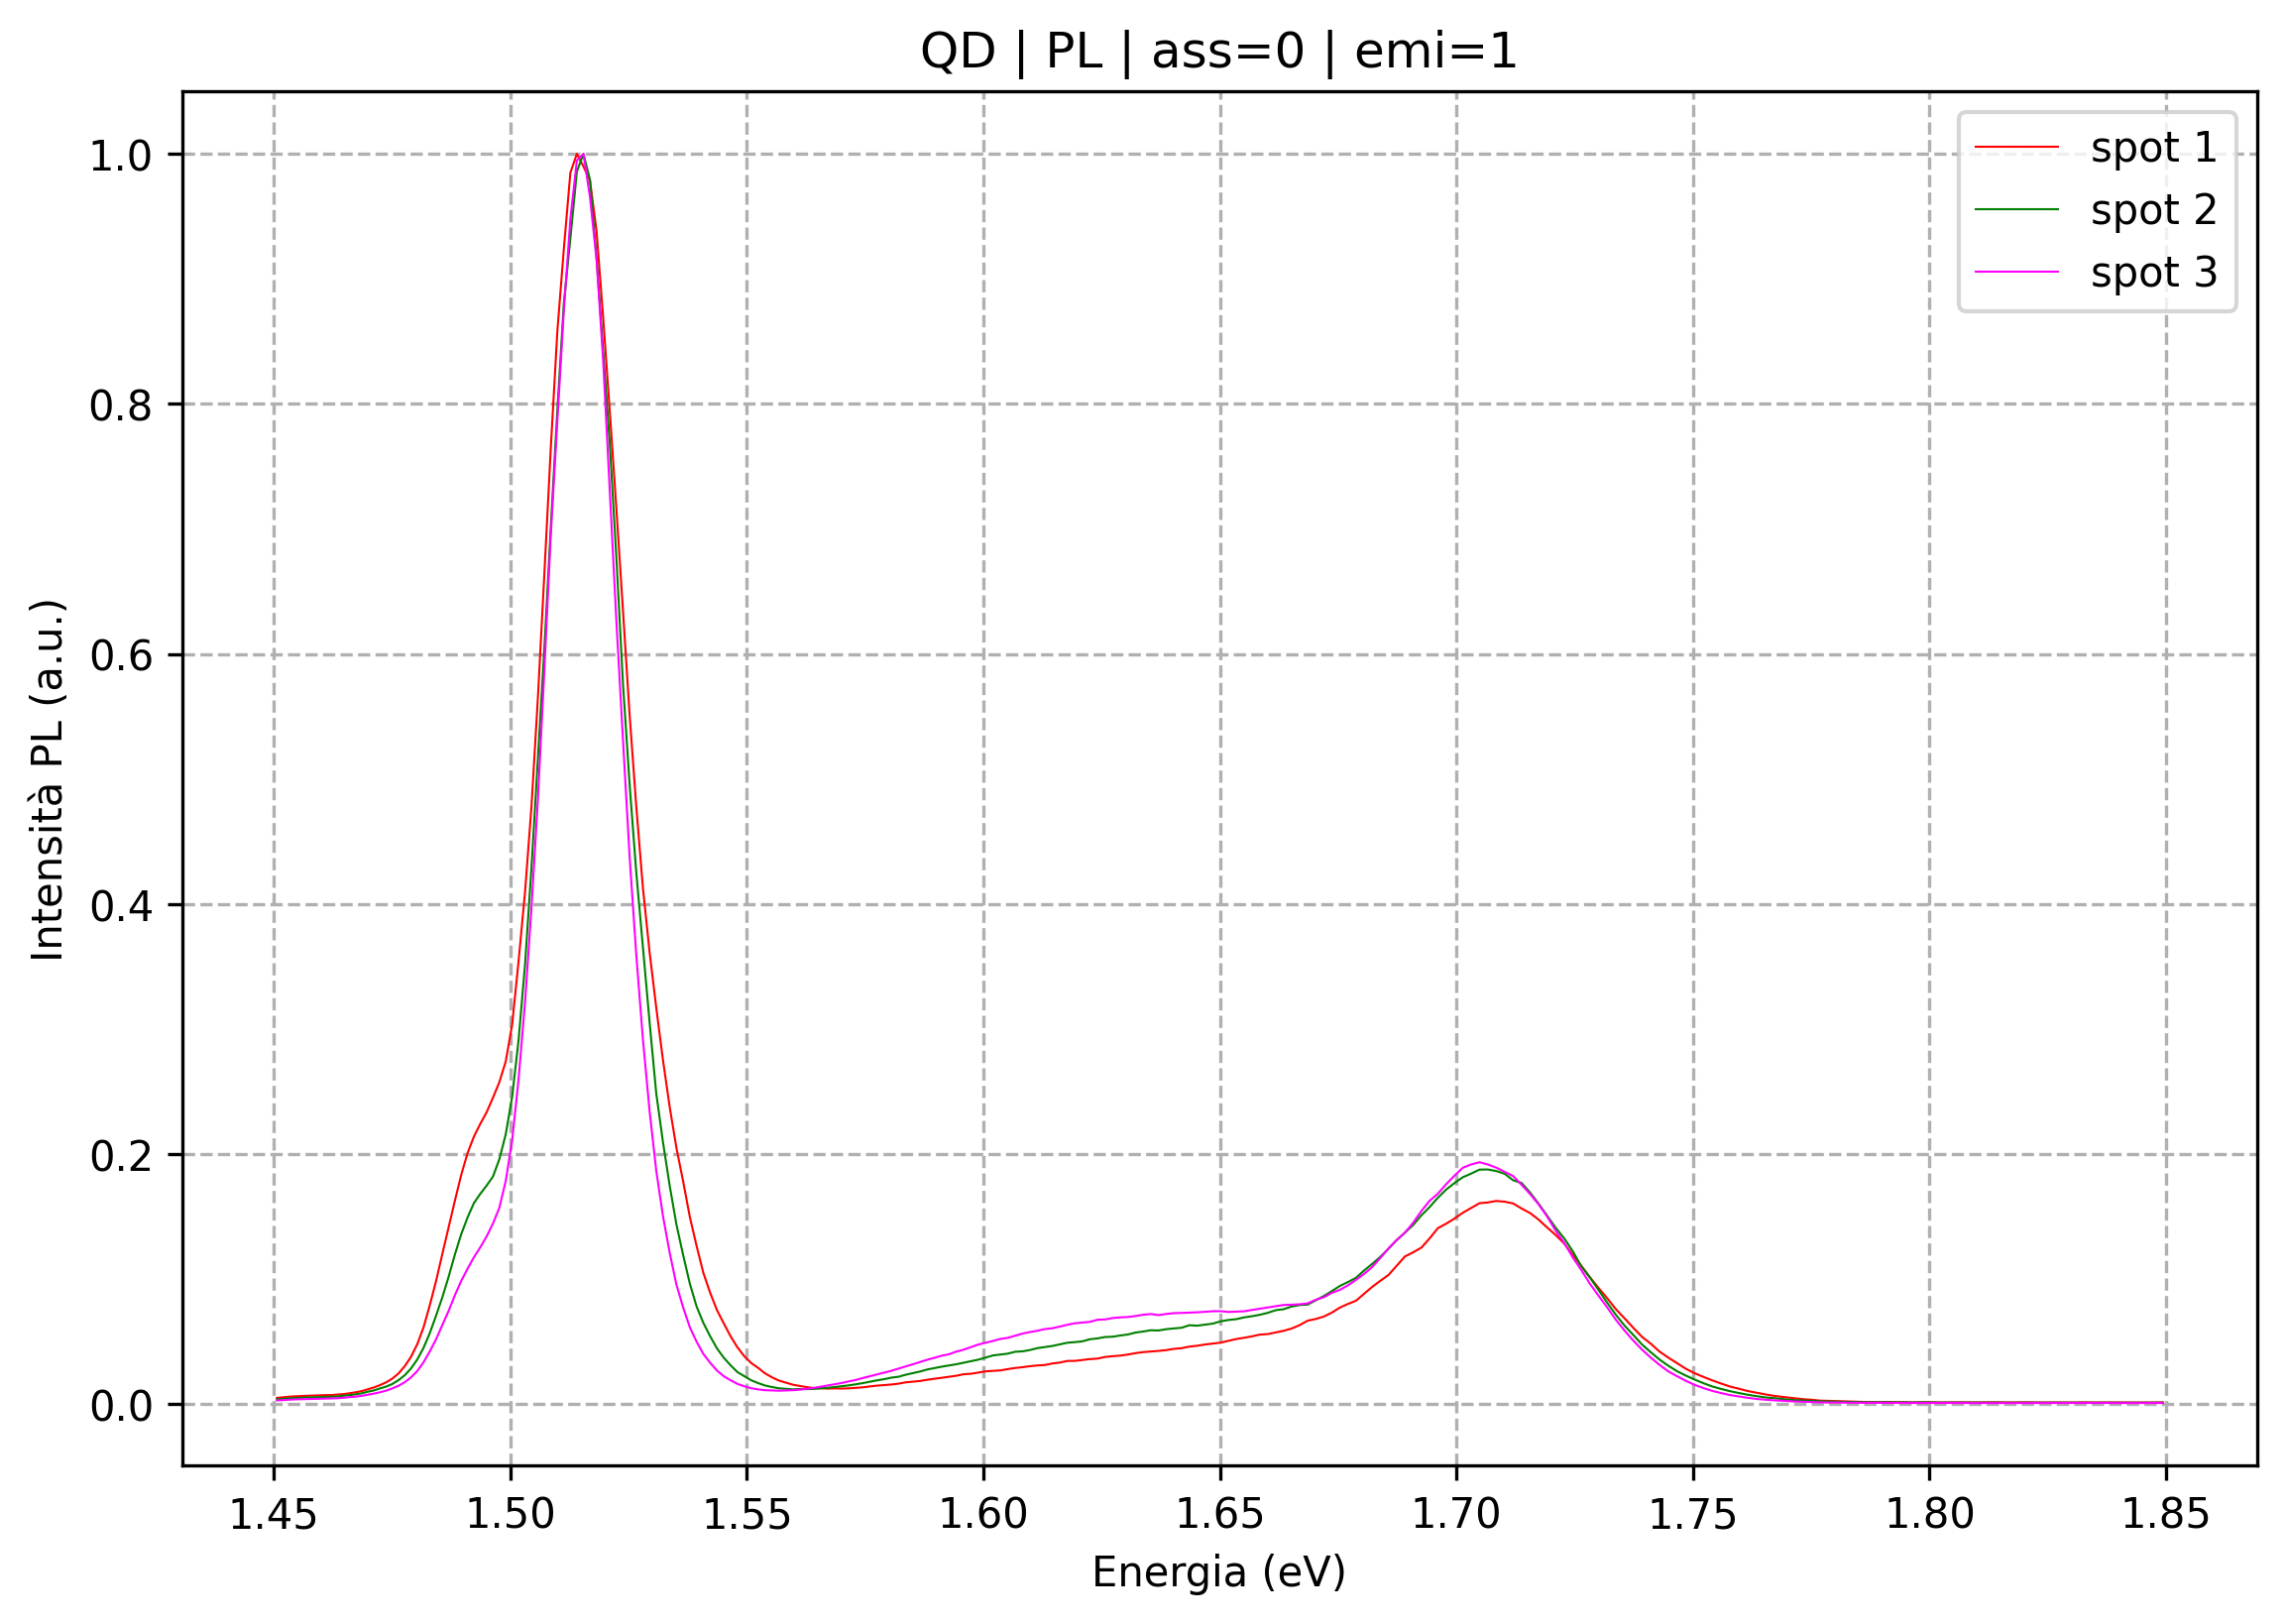

In [ ]:
### Plot gaussiane al variare di T per ass=0 emi=1
plt.figure(figsize=(9, 6), dpi=300)

i=0

# per ogni temperatura, estraggo sigma e a corrispondenti a ass=0 emi=1 e plotto la gaussiana 
for x, y in zip(x_sovra,y_sovra):
    if len(y) > 0:
        plt.plot(x, y, linestyle='-', color=col[i], linewidth=0.5, label='spot '+str(arr_spot[i]))
    i+=1
# Aggiungere etichette e legenda
plt.title('QD | PL | ass=0 | emi=1')
plt.xlabel('Energia (eV)')
plt.ylabel('Intensità PL (a.u.)')
plt.grid(linestyle='--')
plt.legend()

# Mostrare il grafico
plt.show()